# Q-Learning Agent in a Dynamic Obstacle Environment

This notebook demonstrates a Q-learning agent learning to navigate a grid-based environment with moving obstacles. The agent's goal is to reach a target location while avoiding collisions with dynamic obstacles.

## 1. Environment (`DynamicEnv` Class)

The `DynamicEnv` class simulates a 2D grid world. Key features include:
-   **Grid Size**: Customizable grid dimensions.
-   **Robot**: Starts at `(0,0)`.
-   **Goal**: A fixed target location, e.g., `(8,8)`.
-   **Dynamic Obstacles**: Obstacles move according to defined velocities and bounce off grid boundaries. The environment also predicts obstacle movements to penalize 'near collisions'.
-   **Actions**: The robot can move `forward`, `left`, or `right`.
-   **Rewards**:
    -   `+100` for reaching the goal.
    -   `-100` for colliding with an obstacle.
    -   `-5` for a 'near collision' (moving into a space where an obstacle will be in the next step).
    -   `-1` for each regular step (encourages efficiency).

## 2. Q-Learning Implementation

The agent uses the Q-learning algorithm to learn an optimal policy:
-   **Actions**: Defined as `0` (forward), `1` (left), `2` (right).
-   **Q-Table (`Q`)**: A dictionary storing Q-values for `(state, action)` pairs. States are represented by the robot's `(x, y)` coordinates.
-   **`get_q(state, action)`**: Retrieves the Q-value for a given state-action pair, returning `0` if unknown.
-   **`epsilon_greedy(state, eps)`**: Implements an epsilon-greedy policy for action selection. With probability `eps`, a random action is chosen (exploration); otherwise, the action with the highest Q-value is selected (exploitation).

## 3. Training Loop

The agent is trained over a specified number of `episodes`:
-   **Parameters**:
    -   `episodes`: Number of training iterations (e.g., 1000).
    -   `eps` (epsilon): Initial exploration rate, decaying over time.
    -   `alpha` (learning rate): Controls how much new information overrides old information.
    -   `gamma` (discount factor): Determines the importance of future rewards.
-   **Process**:
    1.  Initialize the environment and `total` reward for the episode.
    2.  For each `step` (up to a maximum, e.g., 200):
        -   Select an `action` using the `epsilon_greedy` policy.
        -   Execute the `action` in the environment to get `next_state`, `reward`, and `done` status.
        -   Update the Q-value for the `(state, action)` pair using the Q-learning update rule:
            `Q(s,a) = Q(s,a) + alpha * (reward + gamma * max(Q(s',a')) - Q(s,a))`
        -   Update the current `state`.
        -   Accumulate `reward`.
        -   Break if `done` (goal reached or collision).
    3.  Store the `total` reward for the episode.
    4.  Decay `eps` to reduce exploration over time.

## 4. Learning Curve

A plot of `rewards` per `episode` is generated using `matplotlib`. This visualization helps to understand the agent's learning progress and convergence.

Episode 0: Total Reward = -217, Epsilon = 0.4995
Episode 500: Total Reward = -247, Epsilon = 0.3029
Episode 1000: Total Reward = -200, Epsilon = 0.1837
Episode 1500: Total Reward = -205, Epsilon = 0.1114
Episode 2000: Total Reward = 81, Epsilon = 0.0675
Episode 2500: Total Reward = 81, Epsilon = 0.0410
Episode 3000: Total Reward = 81, Epsilon = 0.0248
Episode 3500: Total Reward = 81, Epsilon = 0.0151
Episode 4000: Total Reward = 81, Epsilon = 0.0091
Episode 4500: Total Reward = 81, Epsilon = 0.0055


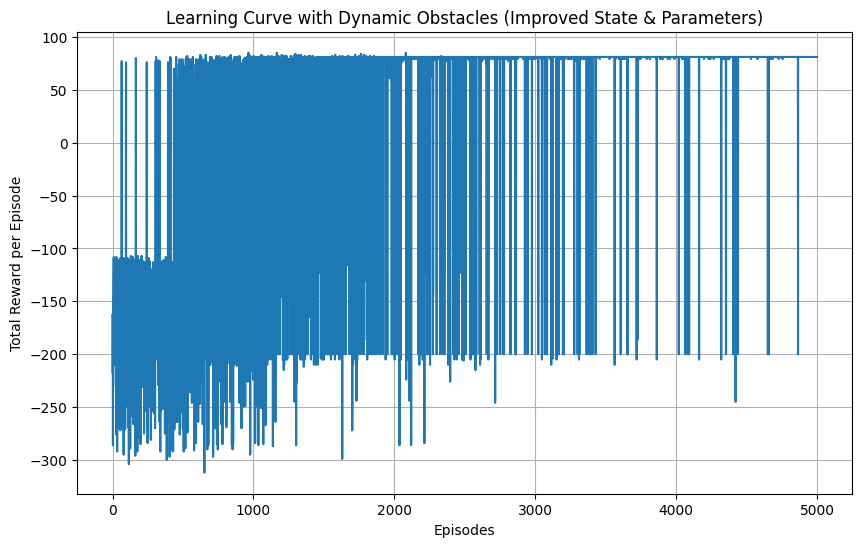

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [2,4, 1,0],
            [4,2, 1,1],
            [3,7, 0,1]
        ]
        self.initial_obstacles = [obs[:] for obs in self.obstacles] # Store initial state for reset
        self.robot_path_history = [] # New: Store robot's path
        self.obstacles_path_history = [] # New: Store obstacles' paths

    def reset(self):
        self.robot = (0,0)
        self.obstacles = [obs[:] for obs in self.initial_obstacles] # Reset obstacles to initial state
        self.robot_path_history = [] # New: Clear path history
        self.obstacles_path_history = [] # New: Clear obstacles path history
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            # Bounce off walls
            if obs[0] < 0:
                obs[0] = 0
                obs[2] *= -1
            elif obs[0] >= self.size:
                obs[0] = self.size - 1
                obs[2] *= -1
            if obs[1] < 0:
                obs[1] = 0
                obs[3] *= -1
            elif obs[1] >= self.size:
                obs[1] = self.size - 1
                obs[3] *= -1

    def predict_obstacles(self):
        predicted = []
        for obs in self.obstacles:
            px = obs[0] + obs[2]
            py = obs[1] + obs[3]
            # Predict bounce if it hits a wall
            if px < 0: px = 0
            elif px >= self.size: px = self.size - 1
            if py < 0: py = 0
            elif py >= self.size: py = self.size - 1
            predicted.append((px, py))
        return predicted

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward (move in x-direction)
        if action == 1: y = max(0, y-1)             # left (move in -y direction)
        if action == 2: y = min(self.size-1, y+1)   # right (move in +y direction)

        # Ensure robot stays within bounds
        x = max(0, min(self.size - 1, x))
        y = max(0, min(self.size - 1, y))

        self.robot = (x,y)
        self.robot_path_history.append(self.robot) # New: Record robot position

        # Move dynamic obstacles
        self.move_obstacles()
        self.obstacles_path_history.append([(o[0], o[1]) for o in self.obstacles]) # New: Record obstacle positions

        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        # Check current robot position against current obstacle positions
        for obs_coords in [(o[0], o[1]) for o in self.obstacles]:
            if (x,y) == obs_coords:
                return self.get_state(), -100, True # Collision

        # Check current robot position against predicted next obstacle positions (near collision)
        if (x,y) in pred:
            reward -= 5  # near collision penalty

        if (x,y) == self.goal:
            return self.get_state(), 100, True # Goal reached

        return self.get_state(), reward, False

    def get_state(self):
        # State now includes robot position and all obstacle positions
        state_tuple = (*self.robot,) # Robot x, y
        for obs in self.obstacles:
            state_tuple += (obs[0], obs[1]) # Add each obstacle's x, y
        return state_tuple


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0.0) # Ensure float for Q-values

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    # If all Q-values are 0 (unexplored), choose randomly among them
    # Otherwise, choose the one with the highest Q-value
    if all(q == 0 for q in qs):
        return random.choice(actions)
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 5000 # Increased episodes
eps = 0.5     # Slightly higher initial epsilon for more exploration
alpha = 0.1
gamma = 0.95  # Increased gamma for more future reward consideration

rewards = []
successful_episodes = 0 # Counter for successful episodes

for ep in range(episodes):
    state = env.reset()
    total = 0
    episode_steps = 0 # To count steps per episode

    for t in range(200): # Max steps per episode
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        # Q-learning update rule
        best_next_q = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha * (reward + gamma * best_next_q - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward
        episode_steps += 1

        if done:
            # If the goal was reached, increment successful_episodes
            if reward == 100: # Check if the goal reward was received
                successful_episodes += 1
            break

    rewards.append(total)
    eps *= 0.999 # Slower epsilon decay

    if ep % 500 == 0: # Print progress occasionally
        print(f"Episode {ep}: Total Reward = {total}, Epsilon = {eps:.4f}")

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.figure(figsize=(10,6))
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles (Improved State & Parameters)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.grid(True)
plt.show()


Episode 0: Total Reward = -217, Epsilon = 0.4995
Episode 500: Total Reward = -247, Epsilon = 0.3029
Episode 1000: Total Reward = -200, Epsilon = 0.1837
Episode 1500: Total Reward = -205, Epsilon = 0.1114
Episode 2000: Total Reward = 81, Epsilon = 0.0675
Episode 2500: Total Reward = 81, Epsilon = 0.0410
Episode 3000: Total Reward = 81, Epsilon = 0.0248
Episode 3500: Total Reward = 81, Epsilon = 0.0151
Episode 4000: Total Reward = 81, Epsilon = 0.0091
Episode 4500: Total Reward = 81, Epsilon = 0.0055


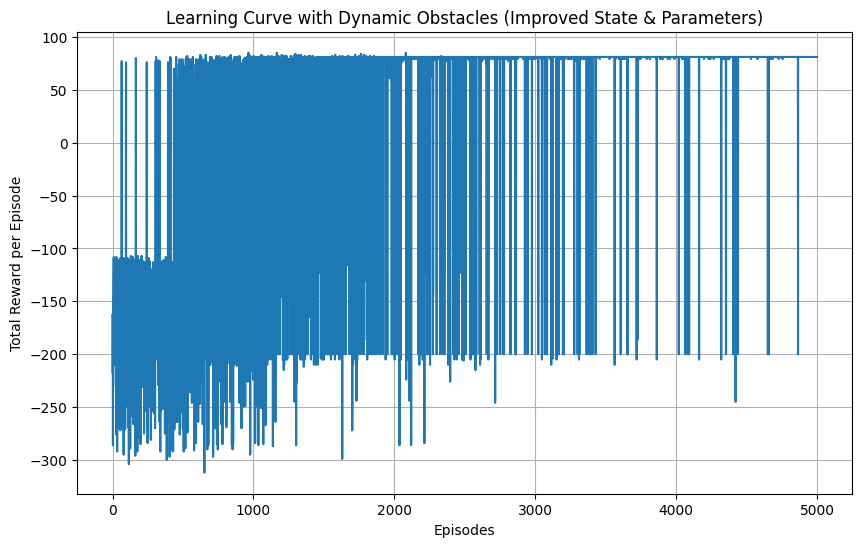

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [2,4, 1,0],
            [4,2, 1,1],
            [3,7, 0,1]
        ]
        self.initial_obstacles = [obs[:] for obs in self.obstacles] # Store initial state for reset
        self.robot_path_history = [] # New: Store robot's path
        self.obstacles_path_history = [] # New: Store obstacles' paths

    def reset(self):
        self.robot = (0,0)
        self.obstacles = [obs[:] for obs in self.initial_obstacles] # Reset obstacles to initial state
        self.robot_path_history = [] # New: Clear path history
        self.obstacles_path_history = [] # New: Clear obstacles path history
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            # Bounce off walls
            if obs[0] < 0:
                obs[0] = 0
                obs[2] *= -1
            elif obs[0] >= self.size:
                obs[0] = self.size - 1
                obs[2] *= -1
            if obs[1] < 0:
                obs[1] = 0
                obs[3] *= -1
            elif obs[1] >= self.size:
                obs[1] = self.size - 1
                obs[3] *= -1

    def predict_obstacles(self):
        predicted = []
        for obs in self.obstacles:
            px = obs[0] + obs[2]
            py = obs[1] + obs[3]
            # Predict bounce if it hits a wall
            if px < 0: px = 0
            elif px >= self.size: px = self.size - 1
            if py < 0: py = 0
            elif py >= self.size: py = self.size - 1
            predicted.append((px, py))
        return predicted

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward (move in x-direction)
        if action == 1: y = max(0, y-1)             # left (move in -y direction)
        if action == 2: y = min(self.size-1, y+1)   # right (move in +y direction)

        # Ensure robot stays within bounds
        x = max(0, min(self.size - 1, x))
        y = max(0, min(self.size - 1, y))

        self.robot = (x,y)
        self.robot_path_history.append(self.robot) # New: Record robot position

        # Move dynamic obstacles
        self.move_obstacles()
        self.obstacles_path_history.append([(o[0], o[1]) for o in self.obstacles]) # New: Record obstacle positions

        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        # Check current robot position against current obstacle positions
        for obs_coords in [(o[0], o[1]) for o in self.obstacles]:
            if (x,y) == obs_coords:
                return self.get_state(), -100, True # Collision

        # Check current robot position against predicted next obstacle positions (near collision)
        if (x,y) in pred:
            reward -= 5  # near collision penalty

        if (x,y) == self.goal:
            return self.get_state(), 100, True # Goal reached

        return self.get_state(), reward, False

    def get_state(self):
        # State now includes robot position and all obstacle positions
        state_tuple = (*self.robot,) # Robot x, y
        for obs in self.obstacles:
            state_tuple += (obs[0], obs[1]) # Add each obstacle's x, y
        return state_tuple


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0.0) # Ensure float for Q-values

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    # If all Q-values are 0 (unexplored), choose randomly among them
    # Otherwise, choose the one with the highest Q-value
    if all(q == 0 for q in qs):
        return random.choice(actions)
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 5000 # Increased episodes
eps = 0.5     # Slightly higher initial epsilon for more exploration
alpha = 0.1
gamma = 0.95  # Increased gamma for more future reward consideration

rewards = []
successful_episodes = 0 # Counter for successful episodes

for ep in range(episodes):
    state = env.reset()
    total = 0
    episode_steps = 0 # To count steps per episode

    for t in range(200): # Max steps per episode
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        # Q-learning update rule
        best_next_q = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha * (reward + gamma * best_next_q - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward
        episode_steps += 1

        if done:
            # If the goal was reached, increment successful_episodes
            if reward == 100: # Check if the goal reward was received
                successful_episodes += 1
            break

    rewards.append(total)
    eps *= 0.999 # Slower epsilon decay

    if ep % 500 == 0: # Print progress occasionally
        print(f"Episode {ep}: Total Reward = {total}, Epsilon = {eps:.4f}")

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.figure(figsize=(10,6))
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles (Improved State & Parameters)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.grid(True)
plt.show()


Episode 0: Total Reward = -217, Epsilon = 0.4995
Episode 500: Total Reward = -247, Epsilon = 0.3029
Episode 1000: Total Reward = -200, Epsilon = 0.1837
Episode 1500: Total Reward = -205, Epsilon = 0.1114
Episode 2000: Total Reward = 81, Epsilon = 0.0675
Episode 2500: Total Reward = 81, Epsilon = 0.0410
Episode 3000: Total Reward = 81, Epsilon = 0.0248
Episode 3500: Total Reward = 81, Epsilon = 0.0151
Episode 4000: Total Reward = 81, Epsilon = 0.0091
Episode 4500: Total Reward = 81, Epsilon = 0.0055


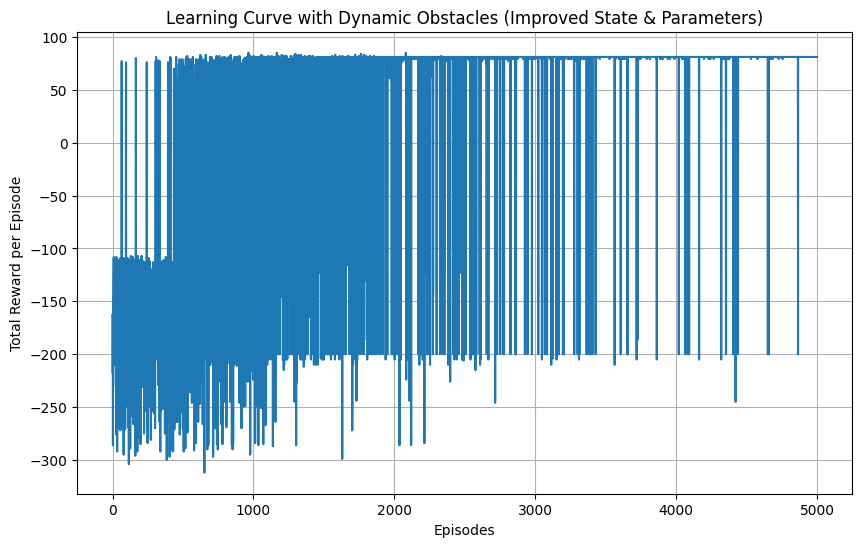

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [2,4, 1,0],
            [4,2, 1,1],
            [3,7, 0,1]
        ]
        self.initial_obstacles = [obs[:] for obs in self.obstacles] # Store initial state for reset
        self.robot_path_history = [] # New: Store robot's path
        self.obstacles_path_history = [] # New: Store obstacles' paths

    def reset(self):
        self.robot = (0,0)
        self.obstacles = [obs[:] for obs in self.initial_obstacles] # Reset obstacles to initial state
        self.robot_path_history = [] # New: Clear path history
        self.obstacles_path_history = [] # New: Clear obstacles path history
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            # Bounce off walls
            if obs[0] < 0:
                obs[0] = 0
                obs[2] *= -1
            elif obs[0] >= self.size:
                obs[0] = self.size - 1
                obs[2] *= -1
            if obs[1] < 0:
                obs[1] = 0
                obs[3] *= -1
            elif obs[1] >= self.size:
                obs[1] = self.size - 1
                obs[3] *= -1

    def predict_obstacles(self):
        predicted = []
        for obs in self.obstacles:
            px = obs[0] + obs[2]
            py = obs[1] + obs[3]
            # Predict bounce if it hits a wall
            if px < 0: px = 0
            elif px >= self.size: px = self.size - 1
            if py < 0: py = 0
            elif py >= self.size: py = self.size - 1
            predicted.append((px, py))
        return predicted

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward (move in x-direction)
        if action == 1: y = max(0, y-1)             # left (move in -y direction)
        if action == 2: y = min(self.size-1, y+1)   # right (move in +y direction)

        # Ensure robot stays within bounds
        x = max(0, min(self.size - 1, x))
        y = max(0, min(self.size - 1, y))

        self.robot = (x,y)
        self.robot_path_history.append(self.robot) # New: Record robot position

        # Move dynamic obstacles
        self.move_obstacles()
        self.obstacles_path_history.append([(o[0], o[1]) for o in self.obstacles]) # New: Record obstacle positions

        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        # Check current robot position against current obstacle positions
        for obs_coords in [(o[0], o[1]) for o in self.obstacles]:
            if (x,y) == obs_coords:
                return self.get_state(), -100, True # Collision

        # Check current robot position against predicted next obstacle positions (near collision)
        if (x,y) in pred:
            reward -= 5  # near collision penalty

        if (x,y) == self.goal:
            return self.get_state(), 100, True # Goal reached

        return self.get_state(), reward, False

    def get_state(self):
        # State now includes robot position and all obstacle positions
        state_tuple = (*self.robot,) # Robot x, y
        for obs in self.obstacles:
            state_tuple += (obs[0], obs[1]) # Add each obstacle's x, y
        return state_tuple


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0.0) # Ensure float for Q-values

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    # If all Q-values are 0 (unexplored), choose randomly among them
    # Otherwise, choose the one with the highest Q-value
    if all(q == 0 for q in qs):
        return random.choice(actions)
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 5000 # Increased episodes
eps = 0.5     # Slightly higher initial epsilon for more exploration
alpha = 0.1
gamma = 0.95  # Increased gamma for more future reward consideration

rewards = []
successful_episodes = 0 # Counter for successful episodes

for ep in range(episodes):
    state = env.reset()
    total = 0
    episode_steps = 0 # To count steps per episode

    for t in range(200): # Max steps per episode
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        # Q-learning update rule
        best_next_q = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha * (reward + gamma * best_next_q - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward
        episode_steps += 1

        if done:
            # If the goal was reached, increment successful_episodes
            if reward == 100: # Check if the goal reward was received
                successful_episodes += 1
            break

    rewards.append(total)
    eps *= 0.999 # Slower epsilon decay

    if ep % 500 == 0: # Print progress occasionally
        print(f"Episode {ep}: Total Reward = {total}, Epsilon = {eps:.4f}")

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.figure(figsize=(10,6))
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles (Improved State & Parameters)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.grid(True)
plt.show()


Episode 0: Total Reward = -217, Epsilon = 0.4995
Episode 500: Total Reward = -247, Epsilon = 0.3029
Episode 1000: Total Reward = -200, Epsilon = 0.1837
Episode 1500: Total Reward = -205, Epsilon = 0.1114
Episode 2000: Total Reward = 81, Epsilon = 0.0675
Episode 2500: Total Reward = 81, Epsilon = 0.0410
Episode 3000: Total Reward = 81, Epsilon = 0.0248
Episode 3500: Total Reward = 81, Epsilon = 0.0151
Episode 4000: Total Reward = 81, Epsilon = 0.0091
Episode 4500: Total Reward = 81, Epsilon = 0.0055


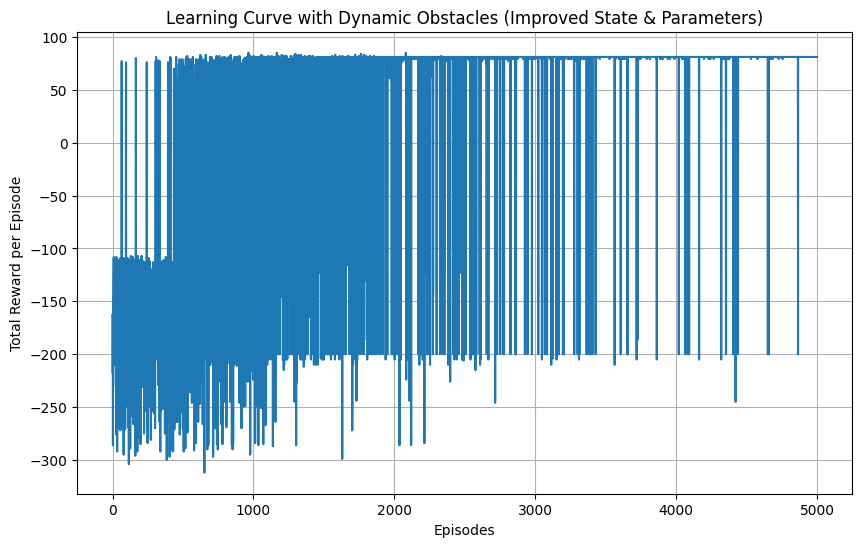

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [2,4, 1,0],
            [4,2, 1,1],
            [3,7, 0,1]
        ]
        self.initial_obstacles = [obs[:] for obs in self.obstacles] # Store initial state for reset
        self.robot_path_history = [] # New: Store robot's path
        self.obstacles_path_history = [] # New: Store obstacles' paths

    def reset(self):
        self.robot = (0,0)
        self.obstacles = [obs[:] for obs in self.initial_obstacles] # Reset obstacles to initial state
        self.robot_path_history = [] # New: Clear path history
        self.obstacles_path_history = [] # New: Clear obstacles path history
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            # Bounce off walls
            if obs[0] < 0:
                obs[0] = 0
                obs[2] *= -1
            elif obs[0] >= self.size:
                obs[0] = self.size - 1
                obs[2] *= -1
            if obs[1] < 0:
                obs[1] = 0
                obs[3] *= -1
            elif obs[1] >= self.size:
                obs[1] = self.size - 1
                obs[3] *= -1

    def predict_obstacles(self):
        predicted = []
        for obs in self.obstacles:
            px = obs[0] + obs[2]
            py = obs[1] + obs[3]
            # Predict bounce if it hits a wall
            if px < 0: px = 0
            elif px >= self.size: px = self.size - 1
            if py < 0: py = 0
            elif py >= self.size: py = self.size - 1
            predicted.append((px, py))
        return predicted

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward (move in x-direction)
        if action == 1: y = max(0, y-1)             # left (move in -y direction)
        if action == 2: y = min(self.size-1, y+1)   # right (move in +y direction)

        # Ensure robot stays within bounds
        x = max(0, min(self.size - 1, x))
        y = max(0, min(self.size - 1, y))

        self.robot = (x,y)
        self.robot_path_history.append(self.robot) # New: Record robot position

        # Move dynamic obstacles
        self.move_obstacles()
        self.obstacles_path_history.append([(o[0], o[1]) for o in self.obstacles]) # New: Record obstacle positions

        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        # Check current robot position against current obstacle positions
        for obs_coords in [(o[0], o[1]) for o in self.obstacles]:
            if (x,y) == obs_coords:
                return self.get_state(), -100, True # Collision

        # Check current robot position against predicted next obstacle positions (near collision)
        if (x,y) in pred:
            reward -= 5  # near collision penalty

        if (x,y) == self.goal:
            return self.get_state(), 100, True # Goal reached

        return self.get_state(), reward, False

    def get_state(self):
        # State now includes robot position and all obstacle positions
        state_tuple = (*self.robot,) # Robot x, y
        for obs in self.obstacles:
            state_tuple += (obs[0], obs[1]) # Add each obstacle's x, y
        return state_tuple


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0.0) # Ensure float for Q-values

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    # If all Q-values are 0 (unexplored), choose randomly among them
    # Otherwise, choose the one with the highest Q-value
    if all(q == 0 for q in qs):
        return random.choice(actions)
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 5000 # Increased episodes
eps = 0.5     # Slightly higher initial epsilon for more exploration
alpha = 0.1
gamma = 0.95  # Increased gamma for more future reward consideration

rewards = []
successful_episodes = 0 # Counter for successful episodes

for ep in range(episodes):
    state = env.reset()
    total = 0
    episode_steps = 0 # To count steps per episode

    for t in range(200): # Max steps per episode
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        # Q-learning update rule
        best_next_q = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha * (reward + gamma * best_next_q - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward
        episode_steps += 1

        if done:
            # If the goal was reached, increment successful_episodes
            if reward == 100: # Check if the goal reward was received
                successful_episodes += 1
            break

    rewards.append(total)
    eps *= 0.999 # Slower epsilon decay

    if ep % 500 == 0: # Print progress occasionally
        print(f"Episode {ep}: Total Reward = {total}, Epsilon = {eps:.4f}")

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.figure(figsize=(10,6))
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles (Improved State & Parameters)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.grid(True)
plt.show()


Episode 0: Total Reward = -217, Epsilon = 0.4995
Episode 500: Total Reward = -247, Epsilon = 0.3029
Episode 1000: Total Reward = -200, Epsilon = 0.1837
Episode 1500: Total Reward = -205, Epsilon = 0.1114
Episode 2000: Total Reward = 81, Epsilon = 0.0675
Episode 2500: Total Reward = 81, Epsilon = 0.0410
Episode 3000: Total Reward = 81, Epsilon = 0.0248
Episode 3500: Total Reward = 81, Epsilon = 0.0151
Episode 4000: Total Reward = 81, Epsilon = 0.0091
Episode 4500: Total Reward = 81, Epsilon = 0.0055


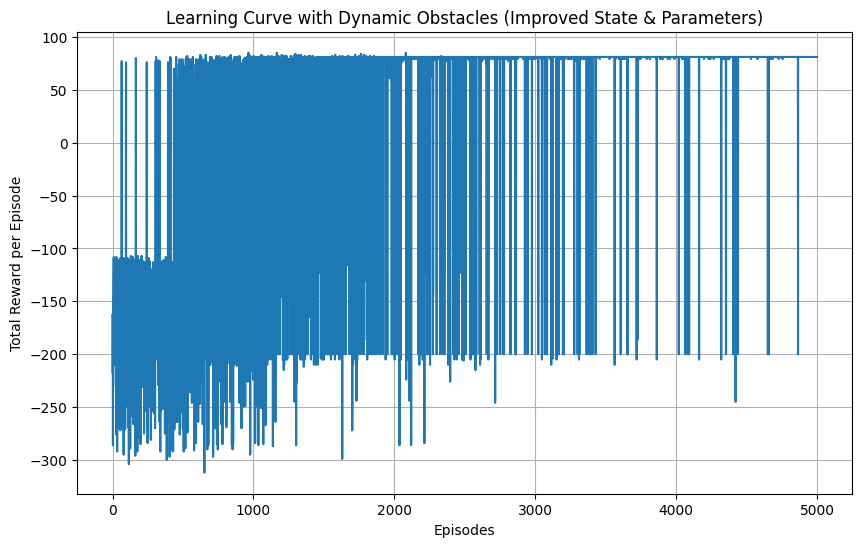

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [2,4, 1,0],
            [4,2, 1,1],
            [3,7, 0,1]
        ]
        self.initial_obstacles = [obs[:] for obs in self.obstacles] # Store initial state for reset
        self.robot_path_history = [] # New: Store robot's path
        self.obstacles_path_history = [] # New: Store obstacles' paths

    def reset(self):
        self.robot = (0,0)
        self.obstacles = [obs[:] for obs in self.initial_obstacles] # Reset obstacles to initial state
        self.robot_path_history = [] # New: Clear path history
        self.obstacles_path_history = [] # New: Clear obstacles path history
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            # Bounce off walls
            if obs[0] < 0:
                obs[0] = 0
                obs[2] *= -1
            elif obs[0] >= self.size:
                obs[0] = self.size - 1
                obs[2] *= -1
            if obs[1] < 0:
                obs[1] = 0
                obs[3] *= -1
            elif obs[1] >= self.size:
                obs[1] = self.size - 1
                obs[3] *= -1

    def predict_obstacles(self):
        predicted = []
        for obs in self.obstacles:
            px = obs[0] + obs[2]
            py = obs[1] + obs[3]
            # Predict bounce if it hits a wall
            if px < 0: px = 0
            elif px >= self.size: px = self.size - 1
            if py < 0: py = 0
            elif py >= self.size: py = self.size - 1
            predicted.append((px, py))
        return predicted

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward (move in x-direction)
        if action == 1: y = max(0, y-1)             # left (move in -y direction)
        if action == 2: y = min(self.size-1, y+1)   # right (move in +y direction)

        # Ensure robot stays within bounds
        x = max(0, min(self.size - 1, x))
        y = max(0, min(self.size - 1, y))

        self.robot = (x,y)
        self.robot_path_history.append(self.robot) # New: Record robot position

        # Move dynamic obstacles
        self.move_obstacles()
        self.obstacles_path_history.append([(o[0], o[1]) for o in self.obstacles]) # New: Record obstacle positions

        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        # Check current robot position against current obstacle positions
        for obs_coords in [(o[0], o[1]) for o in self.obstacles]:
            if (x,y) == obs_coords:
                return self.get_state(), -100, True # Collision

        # Check current robot position against predicted next obstacle positions (near collision)
        if (x,y) in pred:
            reward -= 5  # near collision penalty

        if (x,y) == self.goal:
            return self.get_state(), 100, True # Goal reached

        return self.get_state(), reward, False

    def get_state(self):
        # State now includes robot position and all obstacle positions
        state_tuple = (*self.robot,) # Robot x, y
        for obs in self.obstacles:
            state_tuple += (obs[0], obs[1]) # Add each obstacle's x, y
        return state_tuple


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0.0) # Ensure float for Q-values

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    # If all Q-values are 0 (unexplored), choose randomly among them
    # Otherwise, choose the one with the highest Q-value
    if all(q == 0 for q in qs):
        return random.choice(actions)
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 5000 # Increased episodes
eps = 0.5     # Slightly higher initial epsilon for more exploration
alpha = 0.1
gamma = 0.95  # Increased gamma for more future reward consideration

rewards = []
successful_episodes = 0 # Counter for successful episodes

for ep in range(episodes):
    state = env.reset()
    total = 0
    episode_steps = 0 # To count steps per episode

    for t in range(200): # Max steps per episode
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        # Q-learning update rule
        best_next_q = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha * (reward + gamma * best_next_q - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward
        episode_steps += 1

        if done:
            # If the goal was reached, increment successful_episodes
            if reward == 100: # Check if the goal reward was received
                successful_episodes += 1
            break

    rewards.append(total)
    eps *= 0.999 # Slower epsilon decay

    if ep % 500 == 0: # Print progress occasionally
        print(f"Episode {ep}: Total Reward = {total}, Epsilon = {eps:.4f}")

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.figure(figsize=(10,6))
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles (Improved State & Parameters)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.grid(True)
plt.show()


Episode 0: Total Reward = -217, Epsilon = 0.4995
Episode 500: Total Reward = -247, Epsilon = 0.3029
Episode 1000: Total Reward = -200, Epsilon = 0.1837
Episode 1500: Total Reward = -205, Epsilon = 0.1114
Episode 2000: Total Reward = 81, Epsilon = 0.0675
Episode 2500: Total Reward = 81, Epsilon = 0.0410
Episode 3000: Total Reward = 81, Epsilon = 0.0248
Episode 3500: Total Reward = 81, Epsilon = 0.0151
Episode 4000: Total Reward = 81, Epsilon = 0.0091
Episode 4500: Total Reward = 81, Epsilon = 0.0055


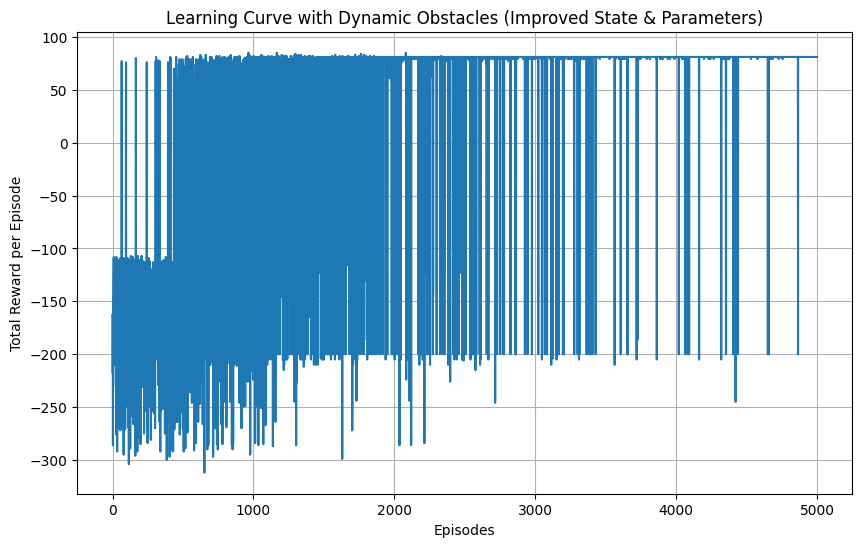

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==============================
# 1. Environment with Dynamic Obstacles
# ==============================
class DynamicEnv:
    def __init__(self, size=10):
        self.size = size
        self.goal = (8,8)
        self.robot = (0,0)
        # Dynamic obstacles: (x, y, vx, vy)
        self.obstacles = [
            [2,4, 1,0],
            [4,2, 1,1],
            [3,7, 0,1]
        ]
        self.initial_obstacles = [obs[:] for obs in self.obstacles] # Store initial state for reset
        self.robot_path_history = [] # New: Store robot's path
        self.obstacles_path_history = [] # New: Store obstacles' paths

    def reset(self):
        self.robot = (0,0)
        self.obstacles = [obs[:] for obs in self.initial_obstacles] # Reset obstacles to initial state
        self.robot_path_history = [] # New: Clear path history
        self.obstacles_path_history = [] # New: Clear obstacles path history
        return self.get_state()

    def move_obstacles(self):
        for obs in self.obstacles:
            obs[0] += obs[2]
            obs[1] += obs[3]

            # Bounce off walls
            if obs[0] < 0:
                obs[0] = 0
                obs[2] *= -1
            elif obs[0] >= self.size:
                obs[0] = self.size - 1
                obs[2] *= -1
            if obs[1] < 0:
                obs[1] = 0
                obs[3] *= -1
            elif obs[1] >= self.size:
                obs[1] = self.size - 1
                obs[3] *= -1

    def predict_obstacles(self):
        predicted = []
        for obs in self.obstacles:
            px = obs[0] + obs[2]
            py = obs[1] + obs[3]
            # Predict bounce if it hits a wall
            if px < 0: px = 0
            elif px >= self.size: px = self.size - 1
            if py < 0: py = 0
            elif py >= self.size: py = self.size - 1
            predicted.append((px, py))
        return predicted

    def step(self, action):
        x, y = self.robot

        if action == 0: x = min(self.size-1, x+1)   # forward (move in x-direction)
        if action == 1: y = max(0, y-1)             # left (move in -y direction)
        if action == 2: y = min(self.size-1, y+1)   # right (move in +y direction)

        # Ensure robot stays within bounds
        x = max(0, min(self.size - 1, x))
        y = max(0, min(self.size - 1, y))

        self.robot = (x,y)
        self.robot_path_history.append(self.robot) # New: Record robot position

        # Move dynamic obstacles
        self.move_obstacles()
        self.obstacles_path_history.append([(o[0], o[1]) for o in self.obstacles]) # New: Record obstacle positions

        pred = self.predict_obstacles()

        reward = -1
        done = False

        # Collision checks
        # Check current robot position against current obstacle positions
        for obs_coords in [(o[0], o[1]) for o in self.obstacles]:
            if (x,y) == obs_coords:
                return self.get_state(), -100, True # Collision

        # Check current robot position against predicted next obstacle positions (near collision)
        if (x,y) in pred:
            reward -= 5  # near collision penalty

        if (x,y) == self.goal:
            return self.get_state(), 100, True # Goal reached

        return self.get_state(), reward, False

    def get_state(self):
        # State now includes robot position and all obstacle positions
        state_tuple = (*self.robot,) # Robot x, y
        for obs in self.obstacles:
            state_tuple += (obs[0], obs[1]) # Add each obstacle's x, y
        return state_tuple


# ==============================
# 2. Q-Learning with Dynamic Obstacles
# ==============================
actions = [0,1,2]  # forward,left,right
Q = {}

def get_q(state, action):
    return Q.get((state, action), 0.0) # Ensure float for Q-values

def epsilon_greedy(state, eps):
    if random.random() < eps:
        return random.choice(actions)
    qs = [get_q(state,a) for a in actions]
    # If all Q-values are 0 (unexplored), choose randomly among them
    # Otherwise, choose the one with the highest Q-value
    if all(q == 0 for q in qs):
        return random.choice(actions)
    return actions[np.argmax(qs)]

# ==============================
# 3. Training Loop
# ==============================
env = DynamicEnv(size=10)
episodes = 5000 # Increased episodes
eps = 0.5     # Slightly higher initial epsilon for more exploration
alpha = 0.1
gamma = 0.95  # Increased gamma for more future reward consideration

rewards = []
successful_episodes = 0 # Counter for successful episodes

for ep in range(episodes):
    state = env.reset()
    total = 0
    episode_steps = 0 # To count steps per episode

    for t in range(200): # Max steps per episode
        action = epsilon_greedy(state, eps)
        next_state, reward, done = env.step(action)

        # Q-learning update rule
        best_next_q = max([get_q(next_state, a) for a in actions])

        old_q = get_q(state, action)
        new_q = old_q + alpha * (reward + gamma * best_next_q - old_q)
        Q[(state, action)] = new_q

        state = next_state
        total += reward
        episode_steps += 1

        if done:
            # If the goal was reached, increment successful_episodes
            if reward == 100: # Check if the goal reward was received
                successful_episodes += 1
            break

    rewards.append(total)
    eps *= 0.999 # Slower epsilon decay

    if ep % 500 == 0: # Print progress occasionally
        print(f"Episode {ep}: Total Reward = {total}, Epsilon = {eps:.4f}")

# ==============================
# 4. Plot Learning Curve
# ==============================
plt.figure(figsize=(10,6))
plt.plot(rewards)
plt.title("Learning Curve with Dynamic Obstacles (Improved State & Parameters)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward per Episode")
plt.grid(True)
plt.show()


Visualization Episode Finished. Total Reward: 81. Steps: 20


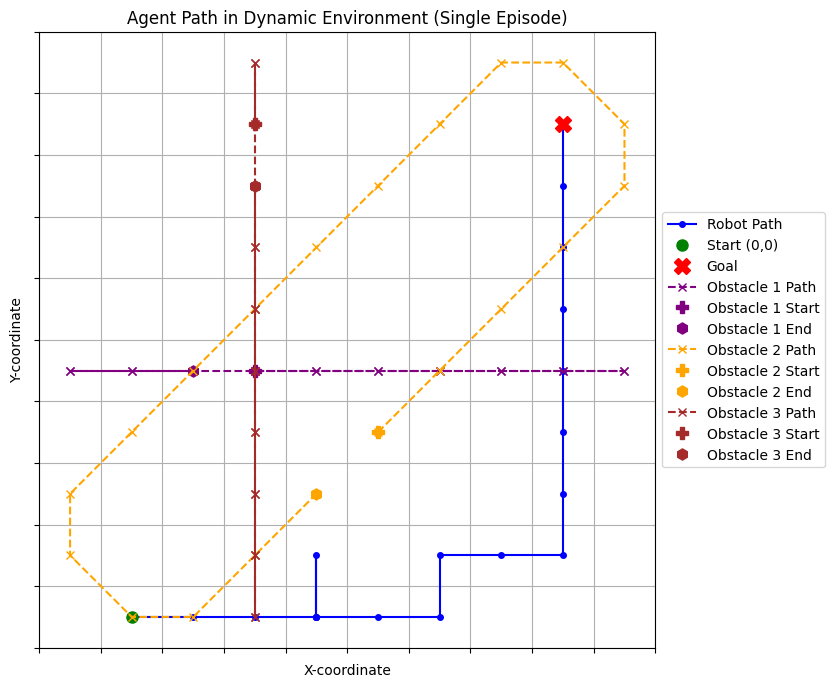

In [ ]:
# ==============================
# 5. Visualize Agent's Path
# ==============================

# Create a fresh environment instance for visualization
# Note: This will not re-train the agent; it uses the already learned Q table.
env_viz = DynamicEnv(size=10)

# Reset the environment for a new episode
state_viz = env_viz.reset()
robot_path = []
obstacle_paths = [[] for _ in range(len(env_viz.obstacles))]

total_reward_viz = 0
done_viz = False

# Run one episode with exploration set to 0 (exploitation only)
for t_viz in range(200): # Max steps for visualization
    # Use learned Q-values to choose the best action (epsilon=0)
    action_viz = epsilon_greedy(state_viz, 0) # No exploration during visualization

    next_state_viz, reward_viz, done_viz = env_viz.step(action_viz)

    # Record the robot's current position from the environment's history
    # The last recorded position is the current one after the step
    if env_viz.robot_path_history:
        robot_path.append(env_viz.robot_path_history[-1])

    # Record obstacle positions from the environment's history
    if env_viz.obstacles_path_history:
        current_obstacle_positions = env_viz.obstacles_path_history[-1]
        for i, obs_pos in enumerate(current_obstacle_positions):
            obstacle_paths[i].append(obs_pos)

    state_viz = next_state_viz
    total_reward_viz += reward_viz

    if done_viz:
        break

print(f"Visualization Episode Finished. Total Reward: {total_reward_viz}. Steps: {len(robot_path)}")

# Plotting the path
plt.figure(figsize=(8,8))

# Plot grid
plt.grid(True)
plt.xticks(np.arange(-0.5, env_viz.size, 1), labels=[])
plt.yticks(np.arange(-0.5, env_viz.size, 1), labels=[])
plt.xlim(-0.5, env_viz.size - 0.5)
plt.ylim(-0.5, env_viz.size - 0.5)

# Plot robot's path
robot_x = [p[0] for p in robot_path]
robot_y = [p[1] for p in robot_path]
plt.plot(robot_x, robot_y, 'o-', color='blue', label='Robot Path', markersize=4)
plt.plot(robot_x[0], robot_y[0], 'o', color='green', markersize=8, label='Start (0,0)')

# Plot goal
goal_x, goal_y = env_viz.goal
plt.plot(goal_x, goal_y, 'X', color='red', markersize=12, label='Goal')

# Plot obstacle paths
colors = ['purple', 'orange', 'brown'] # Different colors for different obstacles
for i, path in enumerate(obstacle_paths):
    obs_x = [p[0] for p in path]
    obs_y = [p[1] for p in path]
    plt.plot(obs_x, obs_y, 'x--', color=colors[i % len(colors)], markersize=6, label=f'Obstacle {i+1} Path')
    # Mark initial and final obstacle positions
    if len(obs_x) > 0:
        plt.plot(obs_x[0], obs_y[0], 'P', color=colors[i % len(colors)], markersize=8, label=f'Obstacle {i+1} Start')
        plt.plot(obs_x[-1], obs_y[-1], 'h', color=colors[i % len(colors)], markersize=8, label=f'Obstacle {i+1} End')

plt.title("Agent Path in Dynamic Environment (Single Episode)")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
# ==============================
# 6. Calculate and Print Success Rate
# ==============================

success_rate = (successful_episodes / episodes) * 100
print(f"Total Episodes: {episodes}")
print(f"Successful Episodes (Goal Reached): {successful_episodes}")
print(f"Success Rate: {success_rate:.2f}%")


Total Episodes: 5000
Successful Episodes (Goal Reached): 3821
Success Rate: 76.42%
